# 04 — Benchmark sur données EEG réelles (TDBRAIN, rTMS / dépression majeure)

Cette notebook évalue le pipeline sur de **vraies** données EEG au lieu du simulateur :
la cohorte **TDBRAIN** de patients dépressifs traités par rTMS
([PMC12981298](https://pmc.ncbi.nlm.nih.gov/articles/PMC12981298/)).

**Réalité de ces données (voir `docs/tdbrain.md`) :**
- **EEG seul** — pas d'ERP/ECG (la piste multimodale reste simulée).
- **Baseline seul** — un enregistrement de repos pré-traitement par patient. Pas de
  trajectoire de séances : l'axe temporel du LSTM est rempli par des **époques** de
  l'enregistrement (`snapshot=True` → classifieur non-temporel).
- **Cible = répondeur binaire** (réduction BDI-II ≥ 50 %).
- **Deux protocoles rTMS évalués séparément** (P1 = 10 Hz L-DLPFC, P2 = 1 Hz R-DLPFC).

> **Prêt pour tes données.** Tant que TDBRAIN n'est pas téléchargé, la notebook
> s'exécute sur un petit jeu **synthétique** au même format (voir la bannière ci-dessous).
> Renseigne `TDBRAIN_ROOT` (chemin de ta copie, ou variable d'environnement du même nom)
> puis ré-exécute : tout le reste est identique.

In [1]:
import os
import sys
import tempfile
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.tdbrain import (
    TDBRAINConfig,
    load_tdbrain,
    make_synthetic_tdbrain,
    tdbrain_features,
)
from src.models.lstm import LSTMConfig
from src.models.train import TrainConfig, cross_validate

# --- Où sont les données ? ---------------------------------------------------
# Renseigne le chemin de ta copie locale de TDBRAIN (le dossier qui contient
# participants.tsv). Par défaut on lit la variable d'environnement TDBRAIN_ROOT,
# sinon data/tdbrain/ à la racine du projet.
TDBRAIN_ROOT = Path(os.environ.get("TDBRAIN_ROOT", ROOT / "data" / "tdbrain"))

USING_SYNTHETIC = not (TDBRAIN_ROOT / "participants.tsv").exists()
if USING_SYNTHETIC:
    # Pas de données réelles -> petit jeu SYNTHÉTIQUE au même format, juste pour que
    # la notebook tourne de bout en bout. Remplace TDBRAIN_ROOT et ré-exécute.
    TDBRAIN_ROOT = Path(tempfile.mkdtemp()) / "tdbrain_synth"
    make_synthetic_tdbrain(TDBRAIN_ROOT, n_patients=12, seed=1)
    LOAD_KW = dict(n_epochs=4, epoch_seconds=1.0)   # enregistrements synthétiques courts
    TRAIN_EPOCHS = 15
    banner = "DONNEES SYNTHETIQUES (demonstration - remplace par TDBRAIN reel)"
else:
    LOAD_KW = dict(n_epochs=8, epoch_seconds=8.0)   # ~64 s d'EEG de repos par patient
    TRAIN_EPOCHS = 40
    banner = f"DONNEES REELLES TDBRAIN : {TDBRAIN_ROOT}"

print("=" * 72)
print(banner)
print("=" * 72)

DONNEES SYNTHETIQUES (demonstration - remplace par TDBRAIN reel)


## 1. Chargement de la cohorte réelle → `LoadedDataset`

In [2]:
def load_cohort(protocols):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # masque le detail des patients exclus
        return load_tdbrain(TDBRAINConfig(root=TDBRAIN_ROOT, protocols=protocols, **LOAD_KW))

ds = load_cohort((1, 2))
print("EEG signals     :", ds.signals.shape, "(patients, epoques, fenetre)")
print("Montage complet :", None if ds.signals_mc is None else ds.signals_mc.shape,
      "(patients, epoques, canaux, fenetre)")
print("Repondeurs      :", int(ds.labels.sum()), "/", len(ds.labels))
print("Protocoles      :", ds.metadata["protocol"].value_counts().to_dict())
print("Modalites ERP/ECG:", ds.erp, "/", ds.ecg, "(EEG seul pour les donnees reelles)")
ds.metadata.head()

EEG signals     :

 (12, 4, 250) (patients, epoques, fenetre)
Montage complet : (12, 4, 26, 250) (patients, epoques, canaux, fenetre)
Repondeurs      : 6 / 12
Protocoles      : {1: 6, 2: 6}
Modalites ERP/ECG: None / None (EEG seul pour les donnees reelles)


,patient_id,protocol,bdi_pre,bdi_post,delta_bdi,pct_reduction,responder
0,10000000,1,27.7,6.9,20.8,0.750903,1
1,10000001,1,34.3,30.8,3.5,0.102041,0
2,10000002,1,28.8,7.2,21.6,0.750000,1
3,10000003,1,31.6,28.5,3.1,0.098101,0
4,10000004,1,20.3,5.1,15.2,0.748768,1


## 2. Extraction de features (band powers multi-canaux)

Un vecteur par époque : puissances relatives des 5 bandes (δ/θ/α/β/γ) sur chacun des
26 canaux. Normalisation **par patient** (aucune fuite inter-patients).

In [3]:
X, y, groups, names = tdbrain_features(ds)
print("X:", X.shape, " ->", X.shape[-1], "features (", len(ds.channels), "canaux x 5 bandes )")
print("Exemple de noms :", names[:3], "...", names[-1])

X: (12, 4, 130)  -> 130 features ( 26 canaux x 5 bandes )
Exemple de noms : ('Fp1_power_delta', 'Fp1_power_theta', 'Fp1_power_alpha') ... O2_power_gamma


## 3. Benchmark — cohorte combinée (validation croisée *patient-wise*)

Même moteur que sur les données simulées (`cross_validate`, `GroupKFold` sur
l'identifiant patient). Le nombre de folds s'adapte à la taille de la cohorte.

In [4]:
def benchmark(dataset, seed=0):
    x, yy, grp, _ = tdbrain_features(dataset)
    n_sub = x.shape[0]
    n_splits = max(2, min(5, n_sub // 2))
    cv = cross_validate(
        x, yy.astype(np.float32), groups=grp,
        lstm_cfg=LSTMConfig(input_size=x.shape[-1], hidden_sizes=(128, 64), dropout=0.3),
        train_cfg=TrainConfig(epochs=TRAIN_EPOCHS, batch_size=8, lr=3e-3,
                              early_stopping_patience=6, seed=seed),
        n_splits=n_splits,
    )
    return cv, n_sub, n_splits


def summarise(cv):
    aucs = np.array([f.auc for f in cv.folds], dtype=float)
    return {
        "accuracy": float(np.nanmean([f.accuracy for f in cv.folds])),
        "auc":      float(np.nanmean(aucs)),
        "f1":       float(np.nanmean([f.f1 for f in cv.folds])),
        "auc_folds_ok": f"{int(np.isfinite(aucs).sum())}/{len(aucs)}",
    }


cv_all, n_all, k_all = benchmark(ds)
print(f"Cohorte combinee : {n_all} patients, {k_all}-fold patient-wise")
for key, val in summarise(cv_all).items():
    print(f"  {key:14s} {val}")

Cohorte combinee : 12 patients, 5-fold patient-wise
  accuracy       0.5666666666666667
  auc            0.6
  f1             0.5599999999999999
  auc_folds_ok   5/5


## 4. Benchmark par protocole rTMS (évalués séparément)

P1 (10 Hz L-DLPFC) et P2 (1 Hz R-DLPFC) sont des traitements différents : on ne les
regroupe pas, sinon la cible « réponse » mélangerait deux mécanismes.

In [5]:
PROTOCOL_NAMES = {1: "10 Hz L-DLPFC", 2: "1 Hz R-DLPFC"}
cv_by_proto = {}
rows = []
for p in (1, 2):
    try:
        ds_p = load_cohort((p,))
        cv_p, n_p, k_p = benchmark(ds_p, seed=p)
        cv_by_proto[p] = cv_p
        rows.append({"protocole": f"P{p} ({PROTOCOL_NAMES[p]})", "n": n_p,
                     "folds": k_p, **summarise(cv_p)})
    except Exception as exc:
        rows.append({"protocole": f"P{p} ({PROTOCOL_NAMES[p]})", "erreur": str(exc)})

proto_df = pd.DataFrame(rows)
proto_df

,protocole,n,folds,accuracy,auc,f1,auc_folds_ok
0,P1 (10 Hz L-DLPFC),6,3,0.500000,0.333333,0.666667,3/3
1,P2 (1 Hz R-DLPFC),6,3,0.666667,0.666667,0.777778,3/3


## 5. AUC par protocole

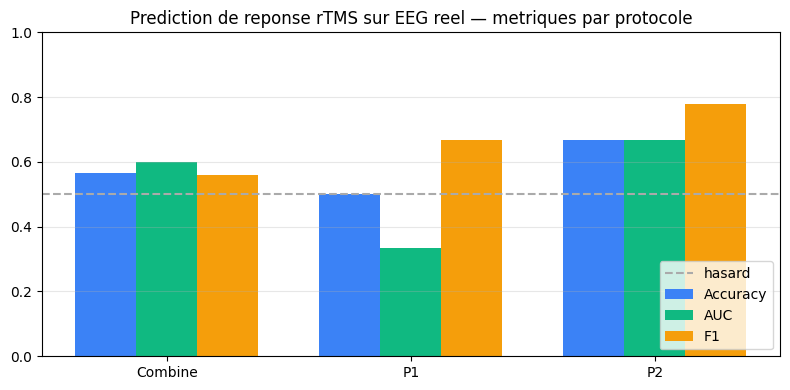

NOTE : chiffres sur donnees SYNTHETIQUES. Sur la vraie cohorte (P1~44, P2~73),
les folds par protocole sont bien peuples et l'AUC est interpretable.


In [6]:
labels_plot = ["Combine"] + [f"P{p}" for p in (1, 2) if p in cv_by_proto]
summaries = [summarise(cv_all)] + [summarise(cv_by_proto[p]) for p in (1, 2) if p in cv_by_proto]
acc = [s["accuracy"] for s in summaries]
auc = [s["auc"] for s in summaries]
f1s = [s["f1"] for s in summaries]

fig, ax = plt.subplots(figsize=(8, 4))
xx = np.arange(len(labels_plot))
ax.bar(xx - 0.25, acc, 0.25, label="Accuracy", color="#3b82f6")
ax.bar(xx,        auc, 0.25, label="AUC",      color="#10b981")
ax.bar(xx + 0.25, f1s, 0.25, label="F1",       color="#f59e0b")
ax.axhline(0.5, color="#aaa", ls="--", label="hasard")
ax.set_xticks(xx); ax.set_xticklabels(labels_plot)
ax.set_ylim(0, 1)
ax.set_title("Prediction de reponse rTMS sur EEG reel — metriques par protocole")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

if USING_SYNTHETIC:
    print("NOTE : chiffres sur donnees SYNTHETIQUES. Sur la vraie cohorte (P1~44, P2~73),"
          "\nles folds par protocole sont bien peuples et l'AUC est interpretable.")

## 6. Courbes de loss par fold (cohorte combinée)

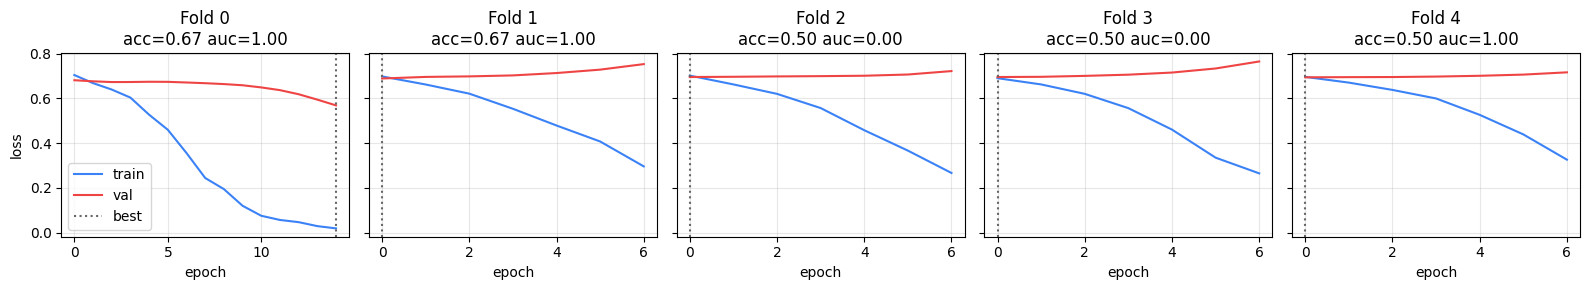

In [7]:
folds = cv_all.folds
fig, axes = plt.subplots(1, len(folds), figsize=(3.2 * len(folds), 3), sharey=True)
axes = np.atleast_1d(axes)
for ax, fold in zip(axes, folds):
    ax.plot(fold.train_losses, label="train", color="#3b82f6")
    ax.plot(fold.val_losses, label="val", color="#ef4444")
    ax.axvline(fold.best_epoch, color="#666", ls=":", label="best")
    ax.set_title(f"Fold {fold.fold}\nacc={fold.accuracy:.2f} auc={fold.auc:.2f}")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0].set_ylabel("loss"); axes[0].legend()
plt.tight_layout(); plt.show()

## Conclusion

- Le pipeline (chargement → features multi-canaux → LSTM, validation **patient-wise**)
  tourne à l'identique sur de l'EEG réel : il suffit de renseigner `TDBRAIN_ROOT`.
- Les deux protocoles rTMS sont évalués **séparément** — ce sont des traitements
  différents ; les regrouper mélangerait les cibles.
- **Attentes honnêtes** : prédire la réponse à partir d'un *seul* EEG de repos
  pré-traitement est difficile. L'étude de référence obtient r ≈ 0.40 / 0.26 (ΔBDI
  continu) *avec* filtrage spatial. Une AUC modeste (~0.6–0.7) sur données réelles est
  un résultat **défendable**, pas un échec — et bien supérieure à l'absence de
  validation réelle.
- Pistes d'amélioration : filtrage spatial / CSP multi-canaux, attention temporelle
  (`LSTMConfig` → flag `use_attention`, cf. `CLAUDE.md`), ou cible régression (ΔBDI,
  déjà conservée dans `metadata`).